Epoch 1/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 163s 36ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 2/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 160s 37ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 3/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 156s 36ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 4/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 160s 36ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 5/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 162s 37ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 6/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 199s 36ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 7/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 160s 36ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 8/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 156s 36ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 9/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 163s 37ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 10/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 158s 36ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 11/50
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 158s 36ms/step - loss: 0.0012 - val_loss: 0.00

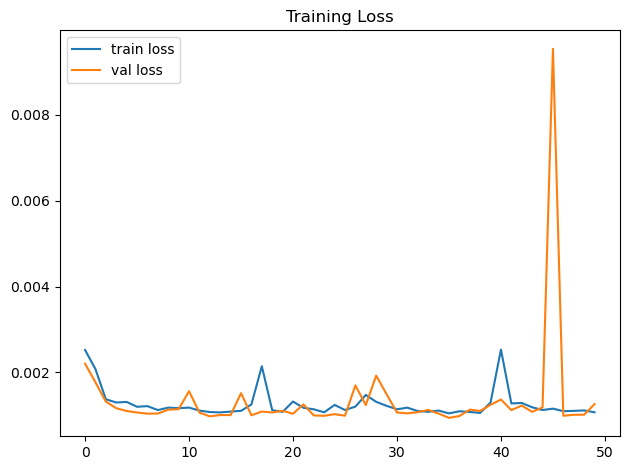

274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
MAE: 11.769, RMSE: 19.280, R²: 0.627


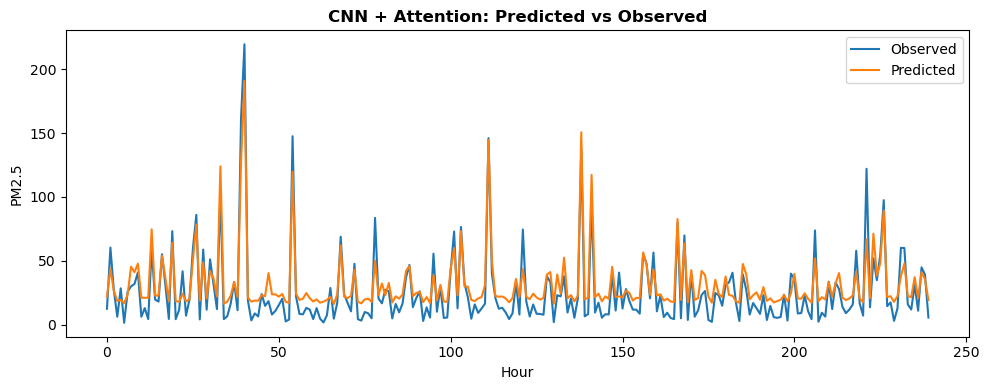

274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


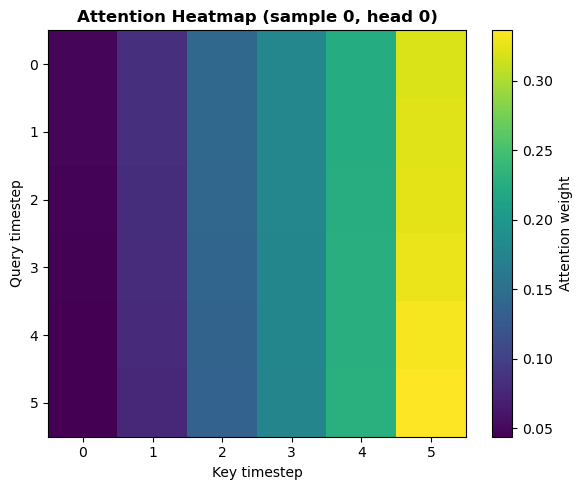

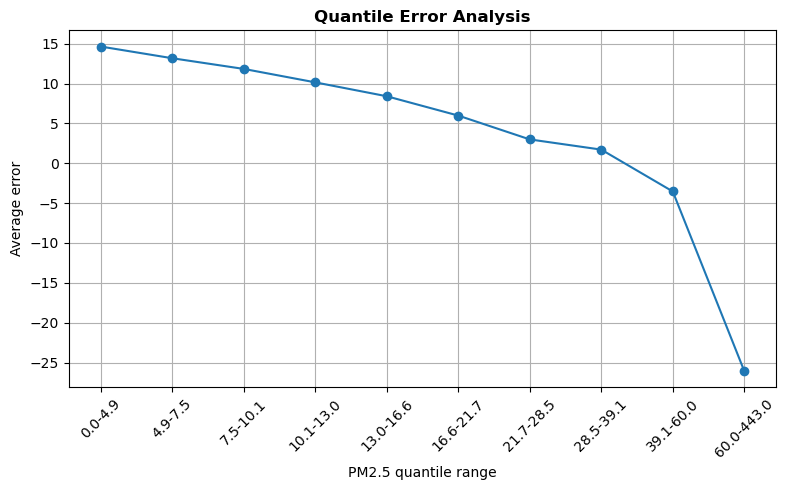

In [1]:
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
from matplotlib import rcParams
from keras.layers import Input, Conv1D, MaxPooling1D, MultiHeadAttention, Flatten, Dense
from keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1) Load & normalize data
dataset = pd.read_csv("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/AirData/eMalahleniIM.csv", sep=';', header=0, index_col=0)
values = dataset.values.astype('float32')
scaler = MinMaxScaler((0, 1))
scaled = scaler.fit_transform(values)

# 2) Helper: series to supervised for n_in lags
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    df = pd.DataFrame(data)
    cols, names = [], []
    n_vars = df.shape[1]
    # input lags
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [f'var{j+1}(t-{i})' for j in range(n_vars)]
    # future steps
    for i in range(n_out):
        cols.append(df.shift(-i))
        suffix = '' if i == 0 else f'+{i}'
        names += [f'var{j+1}(t{suffix})' for j in range(n_vars)]
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg

# 3) Frame with n_in=6, n_out=1
n_in, n_vars = 6, scaled.shape[1]
reframed = series_to_supervised(scaled, n_in, 1)

# 4) Select only the lagged inputs and var1(t) target
n_obs = n_in * n_vars
df_trim = reframed.iloc[:, list(range(n_obs)) + [n_obs]]
vals = df_trim.values
X_all, Y_all = vals[:, :n_obs], vals[:, -1]

# 5) Reshape and split
X = X_all.reshape((X_all.shape[0], n_in, n_vars))
Y = Y_all
X_train, X_tmp, Y_train, Y_tmp = train_test_split(X, Y, test_size=0.20, random_state=42)
X_val, X_test, Y_val, Y_test  = train_test_split(X_tmp, Y_tmp, test_size=0.50, random_state=42)

# 6) Build CNN + Multi‑Head Attention model
inp = Input(shape=(n_in, n_vars), name='input')
x = Conv1D(256, kernel_size=1, activation='relu', padding='same', name='conv1')(inp)
x = MaxPooling1D(pool_size=1, name='pool1')(x)
x = Conv1D(256, kernel_size=1, activation='relu', padding='same', name='conv2')(x)
x = MaxPooling1D(pool_size=1, name='pool2')(x)
x = Conv1D(256, kernel_size=1, activation='relu', padding='same', name='conv3')(x)
x = MaxPooling1D(pool_size=1, name='pool3')(x)

mha = MultiHeadAttention(num_heads=4, key_dim=256, name='mha')
x = mha(query=x, value=x, key=x)
x = Flatten(name='flatten')(x)

for i in range(1, 6):
    x = Dense(56, activation='relu', name=f'dense{i}')(x)

pred = Dense(1, activation='linear', name='pred')(x)
model = Model(inputs=inp, outputs=pred)
model.compile(loss='mse', optimizer='adam')

# 7) Train
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=16, verbose=1)

# 8) Plot training history
#plt.figure()
#plt.plot(history.history['loss'], label='train loss')
#plt.plot(history.history['val_loss'], label='val loss')
#plt.title('Training Loss')
#plt.legend()
#plt.tight_layout()
#plt.show()

# 9) Predict & un‑scale
pred_sc = model.predict(X_test)
y_pred  = pred_sc.flatten() * (scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]
y_true  = Y_test       * (scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]

# 10) Metrics & Pred vs Observed plot
mae  = mean_absolute_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

plt.figure(figsize=(10,4))
plt.plot(y_true[:240], label='Observed')
plt.plot(y_pred[:240], label='Predicted')
plt.title('CNN + Attention: Predicted vs Observed', fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('PM2.5')
plt.legend()
plt.tight_layout()
plt.show()

# 11) Attention heatmap (sample 0, head 0)
# Build inference model for attention scores
inf_inp = Input(shape=(n_in, n_vars), name='inf_input')
y = model.get_layer('conv1')(inf_inp)
y = model.get_layer('pool1')(y)
y = model.get_layer('conv2')(y)
y = model.get_layer('pool2')(y)
y = model.get_layer('conv3')(y)
y = model.get_layer('pool3')(y)
_, attn_scores = mha(query=y, value=y, key=y, return_attention_scores=True)
attn_model = Model(inputs=inf_inp, outputs=attn_scores)

scores = attn_model.predict(X_test)
attn0 = scores[0, 0, :, :]  # sample 0, head 0

plt.figure(figsize=(6,5))
plt.imshow(attn0, aspect='auto', cmap='viridis')
plt.colorbar(label='Attention weight')
plt.title('Attention Heatmap (sample 0, head 0)', fontweight='bold')
plt.xlabel('Key timestep')
plt.ylabel('Query timestep')
plt.tight_layout()
plt.show()

# 12) Quantile error analysis
errors = y_pred - y_true
quantiles, bins = pd.qcut(y_true, 10, duplicates='drop', retbins=True)
quantile_errors = [
    errors[(y_true >= bins[i]) & (y_true < bins[i+1])].mean()
    for i in range(len(bins)-1)]

plt.figure(figsize=(8,5))
plt.plot(range(1, len(quantile_errors)+1), quantile_errors, marker='o')
plt.xticks(
    range(1, len(quantile_errors)+1),
    [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)],
    rotation=45)
plt.title('Quantile Error Analysis', fontweight='bold')
plt.xlabel('PM2.5 quantile range')
plt.ylabel('Average error')
plt.grid(True)
plt.tight_layout()
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 91s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 97s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 94s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 95s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 97s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 95s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 99s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 90s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 89s 13ms/step
1/1 

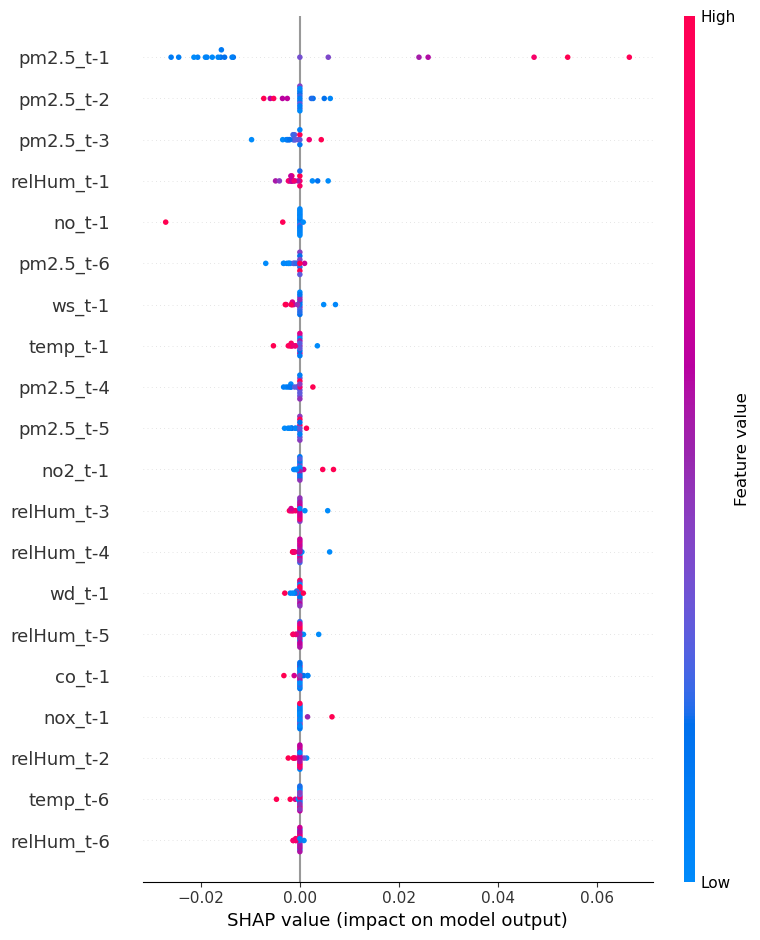

In [2]:
# 13) SHAP analysis
import shap  # only import after training

bg_idx   = np.random.choice(X_train.shape[0], 100, replace=False)
bg_flat  = X_train[bg_idx].reshape(100, n_in * n_vars)
ts_idx   = np.random.choice(X_test.shape[0], 20, replace=False)
test_flat= X_test[ts_idx].reshape(20, n_in * n_vars)

f = lambda x: model.predict(x.reshape(-1, n_in, n_vars)).flatten()
explainer   = shap.KernelExplainer(f, bg_flat)
shap_values = explainer.shap_values(test_flat)

feat_names = [
    f"{col}_t-{lag}"
    for lag in range(n_in, 0, -1)
    for col in dataset.columns
]

shap.summary_plot(shap_values, test_flat, feature_names=feat_names)

# 14) Save model
model.save('cnn_attention_model.h5')
